<a href="https://colab.research.google.com/github/artbelgum/Challenge-Alura-Store/blob/main/Challenge_1_Alura_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [1]:
import pandas as pd #Se importa la biblioteca pandas para analizar datos

#se da la dirección de los archivos csv
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

#Carga los datos en un dataFrame llamado tienda, con la función pd.read_csv
tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

#Vista rápida de las primeras 5 filas del dataframe
tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



Se calculará el ingreso total por cada tienda sumando el precio de cada data. En este caso, df[columna] accede a los datos de la columna especificada en el DataFrame, y luego sum() suma esos valores. Adicional se adjunta un gráfico.

El ingreso total de tienda es: 1150880400.0
El ingreso total de tienda2 es: 1116343500.0
El ingreso total de tienda3 es: 1098019600.0
El ingreso total de tienda4 es: 1038375700.0


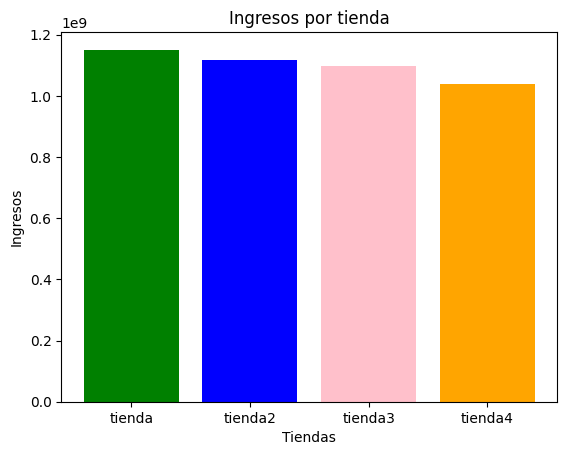

In [11]:
from matplotlib import pyplot as plt #se instala la biblioteca matplotlib

def ingreso_total(nombre_df, df, columna): #función que suma todos los datos de la columna
  ingreso_tienda = df[columna].sum()
  return ingreso_tienda

#Recopilando datos de todas las tiendas
ingreso_tienda = []

#Llamada a la función y almacenamiento de resultados
nombre_tiendas = ['tienda', 'tienda2', 'tienda3', 'tienda4']
dataFrames = [tienda, tienda2, tienda3, tienda4]

for nombre, df in zip(nombre_tiendas, dataFrames):
    ingreso = ingreso_total(nombre, df, 'Precio') #Se llama a la función para obtener el ingreso por tienda
    ingreso_tienda.append(ingreso) #se agrega el ingreso al arreglo
    print(f"El ingreso total de {nombre} es: {ingreso}")

# Definir una lista de colores, para asignar un color por tienda
    colores = ['green', 'blue', 'pink', 'orange']

#Graficando los ingresos por tiendas
plt.bar(nombre_tiendas, ingreso_tienda, color=colores)
plt.xlabel('Tiendas')
plt.ylabel('Ingresos')
plt.title('Ingresos por tienda')
plt.show()

# 2. Ventas por categoría

Se mostrarán la cantidad de artículos vendidos por categoría y la categoría menos vendida.

La categoría menos vendida de tienda es: 'Artículos para el hogar' con 171 ventas y un total de $12698400.00.
La categoría que generó menor venta total es: 'Libros' con un total de $8784900.00.
La categoría menos vendida de tienda2 es: 'Artículos para el hogar' con 181 ventas y un total de $14746900.00.
La categoría que generó menor venta total es: 'Libros' con un total de $10091200.00.
La categoría menos vendida de tienda3 es: 'Instrumentos musicales' con 177 ventas y un total de $77380900.00.
La categoría que generó menor venta total es: 'Libros' con un total de $9498700.00.
La categoría menos vendida de tienda4 es: 'Instrumentos musicales' con 170 ventas y un total de $75102400.00.
La categoría que generó menor venta total es: 'Libros' con un total de $9321300.00.


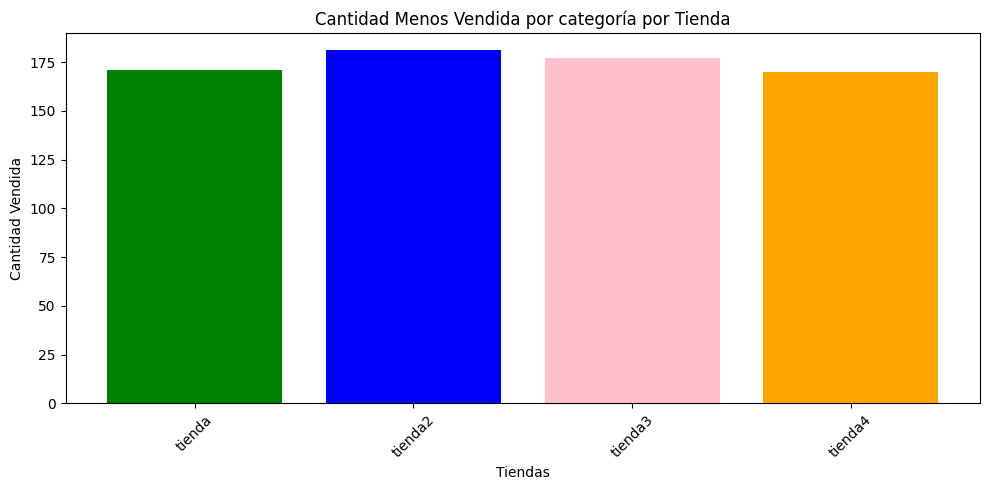

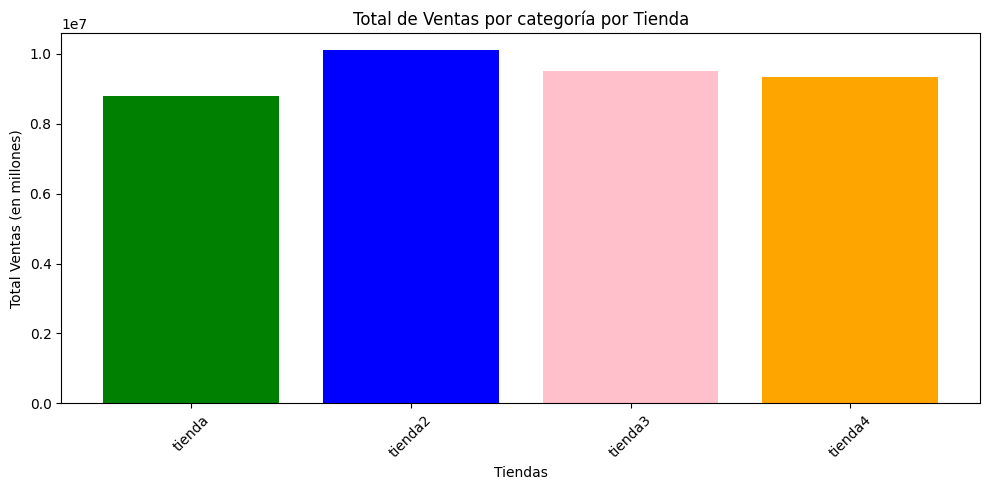

In [30]:
import matplotlib.pyplot as plt #Importación de bibliotecas

def categoria_menos_vendida(tiendas, columna_categoria, columna_ventas): #Definición de función
    categorias_menos_vendidas = [] #inicializando listas
    cantidades_menos_vendidas = []
    categorias_menor_venta = []
    totales_menor_venta = []

    for nombre_df, df in tiendas.items(): #iteración para cada tienda en el diccionario
        cantidad_por_categoria = df[columna_categoria].value_counts() #contando cuántas veces aparece cada categoría en la columna del dataframe
        ventas_por_categoria = df.groupby(columna_categoria)[columna_ventas].sum() #suma las ventas para cada categoría

        categoria_menos_vendida = cantidad_por_categoria.idxmin() #obtiene el nombre de la categoría que tiene menor cantidad vendida
        cantidad_menos_vendida = cantidad_por_categoria.min() #obtiene el valor mínimo de la cantidad vendida
        categoria_menor_venta = ventas_por_categoria.idxmin() #obtiene el nombre de la categoría que tiene la menor venta total
        total_venta_categoria_menor = ventas_por_categoria.min() #obtiene el valor mínimo de las ventas totales

        #Almacenamiento de los resultados
        categorias_menos_vendidas.append(categoria_menos_vendida)
        cantidades_menos_vendidas.append(cantidad_menos_vendida)
        categorias_menor_venta.append(categoria_menor_venta)
        totales_menor_venta.append(total_venta_categoria_menor)

        #Imprimiendo resultados
        print(f"La categoría menos vendida de {nombre_df} es: '{categoria_menos_vendida}' con {cantidad_menos_vendida} ventas y un total de ${ventas_por_categoria[categoria_menos_vendida]:.2f}.")
        print(f"La categoría que generó menor venta total es: '{categoria_menor_venta}' con un total de ${total_venta_categoria_menor:.2f}.")

    #Definiendo colores
    colores = ['green', 'blue', 'pink', 'orange']

    #Gráfica 1: Comparación de la categoría menos vendida
    plt.figure(figsize=(10, 5))
    plt.bar(tiendas.keys(), cantidades_menos_vendidas, color=colores)
    plt.title('Cantidad Menos Vendida por categoría por Tienda')
    plt.xlabel('Tiendas')
    plt.ylabel('Cantidad Vendida')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    #Gráfica 2: Comparación de la categoría que generó menor venta
    plt.figure(figsize=(10, 5))
    plt.bar(tiendas.keys(), totales_menor_venta, color=colores)
    plt.title('Total de Ventas por categoría por Tienda')
    plt.xlabel('Tiendas')
    plt.ylabel('Total Ventas (en millones)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Llamadas a la función con un diccionario de tiendas
tiendas = {
    'tienda': tienda,
    'tienda2': tienda2,
    'tienda3': tienda3,
    'tienda4': tienda4
}

#Llamada a la función
categoria_menos_vendida(tiendas, 'Categoría del Producto', 'Precio')


Se mostrarán la cantidad de artículos vendidos por categoría y la categoría más vendida.

La categoría más vendida de tienda es: 'Muebles' con 465 ventas y un total de $187633700.00.
La categoría que generó mayor venta total es: 'Electrónicos' con un total de $429493500.00.
La categoría más vendida de tienda2 es: 'Muebles' con 442 ventas y un total de $176426300.00.
La categoría que generó mayor venta total es: 'Electrónicos' con un total de $410831100.00.
La categoría más vendida de tienda3 es: 'Muebles' con 499 ventas y un total de $201072100.00.
La categoría que generó mayor venta total es: 'Electrónicos' con un total de $410775800.00.
La categoría más vendida de tienda4 es: 'Muebles' con 480 ventas y un total de $192528900.00.
La categoría que generó mayor venta total es: 'Electrónicos' con un total de $409476100.00.


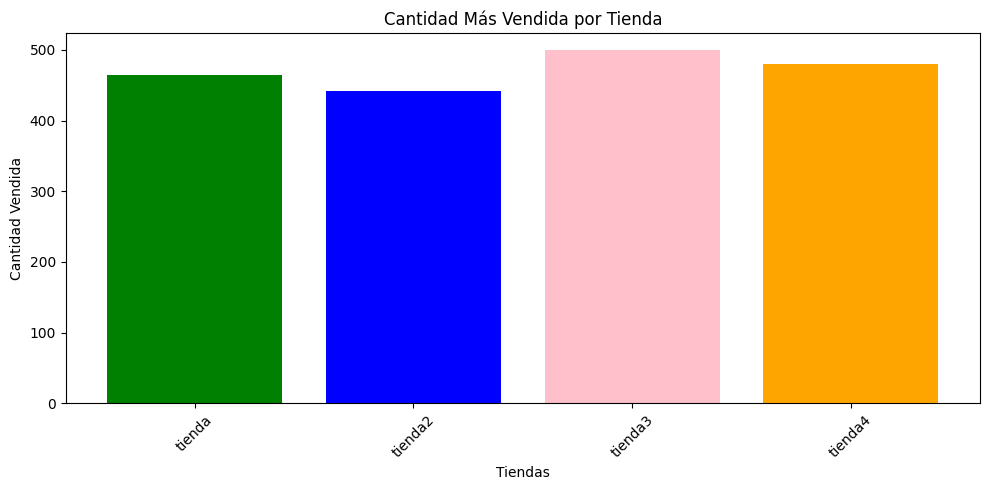

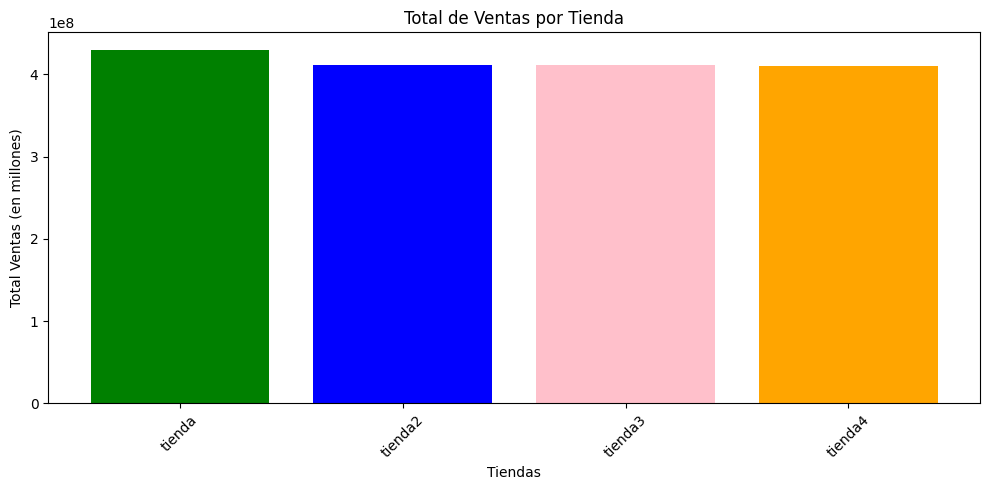

In [10]:
import matplotlib.pyplot as plt

def categoria_mas_vendido(tiendas, columna_categoria, columna_ventas):
    categorias_mas_vendidas = []
    cantidades_mas_vendidas = []
    categorias_mayor_venta = []
    totales_mayor_venta = []

    for nombre_df, df in tiendas.items():
        cantidad_por_categoria = df[columna_categoria].value_counts()
        ventas_por_categoria = df.groupby(columna_categoria)[columna_ventas].sum()

        categoria_mas_vendida = cantidad_por_categoria.idxmax()
        cantidad_mas_vendida = cantidad_por_categoria.max()
        categoria_mayor_venta = ventas_por_categoria.idxmax()
        total_venta_categoria_mayor = ventas_por_categoria.max()

        #Almacenamiento
        categorias_mas_vendidas.append(categoria_mas_vendida)
        cantidades_mas_vendidas.append(cantidad_mas_vendida)
        categorias_mayor_venta.append(categoria_mayor_venta)
        totales_mayor_venta.append(total_venta_categoria_mayor)

        # Imprimir resultados
        print(f"La categoría más vendida de {nombre_df} es: '{categoria_mas_vendida}' con {cantidad_mas_vendida} ventas y un total de ${ventas_por_categoria[categoria_mas_vendida]:.2f}.")
        print(f"La categoría que generó mayor venta total es: '{categoria_mayor_venta}' con un total de ${total_venta_categoria_mayor:.2f}.")

    # Definir una lista de colores, para asignar un color por tienda
    colores = ['green', 'blue', 'pink', 'orange']

    # Gráfica 1: Comparación de la categoría más vendida
    plt.figure(figsize=(10, 5))
    plt.bar(tiendas.keys(), cantidades_mas_vendidas, color=colores)
    plt.title('Cantidad Más Vendida por Tienda')
    plt.xlabel('Tiendas')
    plt.ylabel('Cantidad Vendida')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Gráfica 2: Comparación de la categoría que generó mayor venta
    plt.figure(figsize=(10, 5))
    plt.bar(tiendas.keys(), totales_mayor_venta, color=colores)
    plt.title('Total de Ventas por Tienda')
    plt.xlabel('Tiendas')
    plt.ylabel('Total Ventas (en millones)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Llamadas a la función con un diccionario de tiendas
tiendas = {
    'tienda': tienda,
    'tienda2': tienda2,
    'tienda3': tienda3,
    'tienda4': tienda4
}

# Llamadas a la función
categoria_mas_vendido(tiendas, 'Categoría del Producto', 'Precio')

# 3. Calificación promedio de la tienda


Utilizando la función .mean() que sirve para calcular la media en un DataFrame. Se adjunta gráfico para visualizar a manera de comparación el ingreso de las tiendas.

La calificación de la tienda es de: 3.976685036032217 de 5
La calificación de la tienda2 es de: 4.037303942348453 de 5
La calificación de la tienda3 es de: 4.048325561678677 de 5
La calificación de la tienda4 es de: 3.9957591178965224 de 5


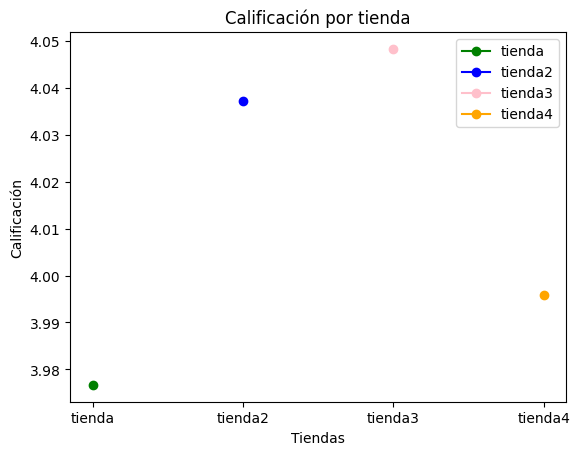

In [14]:
from matplotlib import pyplot as plt

def calificacion_tienda(df, columna):
    calificacion = df[columna].mean()  # Calcula la calificación promedio
    return calificacion  # Devuelve la calificación

# Recopilando datos de todas las tiendas
calificaciones = []  # Cambié el nombre de la lista

# Llamada a la función y almacenamiento de resultados
nombre_tiendas = ['tienda', 'tienda2', 'tienda3', 'tienda4']
dataFrames = [tienda, tienda2, tienda3, tienda4]

for nombre, df in zip(nombre_tiendas, dataFrames):
    puntaje = calificacion_tienda(df, 'Calificación')  # Se llama a la función para obtener el puntaje por tienda
    calificaciones.append(puntaje)  # Se agrega la calificación al arreglo
    print(f"La calificación de la {nombre} es de: {puntaje} de 5")  # Imprime la calificación de cada tienda

# Definir una lista de colores, para asignar un color por tienda
colores = ['green', 'blue', 'pink', 'orange']

# Graficando la calificación por tiendas
for i in range(len(nombre_tiendas)):
    plt.plot(nombre_tiendas[i], calificaciones[i], marker='o', color=colores[i], linestyle='-', label=nombre_tiendas[i])

plt.xlabel('Tiendas')
plt.ylabel('Calificación')
plt.title('Calificación por tienda')
plt.legend()  # Añadir leyenda para identificar cada tienda
plt.show()

# 4. Productos más y menos vendidos

Se mostrará el producto más vendido

In [ ]:
def producto_mas_vendido(nombre_df, df, columna, columna_categoria):
    producto = df[columna].value_counts()  # cuenta cuántas veces aparece cada producto
    producto_mas_vendido = producto.idxmax()  # obtiene el nombre del producto más vendido
    cantidad_mas_vendida = producto.max()  # obtiene la cantidad de productos más vendidos

    # Obtener la categoría del producto más vendido
    categoria_producto = df[df[columna] == producto_mas_vendido][columna_categoria].iloc[0]

    return print(f"El producto más vendido de {nombre_df} es: '{producto_mas_vendido}' con {cantidad_mas_vendida} ventas y pertenece a la categoría: '{categoria_producto}'.\n")

# Llamada a función
producto_mas_vendido('tienda', tienda, 'Producto', 'Categoría del Producto')
producto_mas_vendido('tienda2', tienda2, 'Producto', 'Categoría del Producto')
producto_mas_vendido('tienda3', tienda3, 'Producto', 'Categoría del Producto')
producto_mas_vendido('tienda4', tienda4, 'Producto', 'Categoría del Producto')

El producto más vendido de tienda es: 'Microondas' con 60 ventas y pertenece a la categoría: 'Electrodomésticos'.

El producto más vendido de tienda2 es: 'Iniciando en programación' con 65 ventas y pertenece a la categoría: 'Libros'.

El producto más vendido de tienda3 es: 'Kit de bancas' con 57 ventas y pertenece a la categoría: 'Muebles'.

El producto más vendido de tienda4 es: 'Cama box' con 62 ventas y pertenece a la categoría: 'Muebles'.



Se mostrará el producto menos vendido con .idxmin() y .min()

El producto menos vendido de tienda es: 'Auriculares con micrófono' con 33 ventas y pertenece a la categoría: 'Electrónicos'.
El producto menos vendido de tienda2 es: 'Juego de mesa' con 32 ventas y pertenece a la categoría: 'Juguetes'.
El producto menos vendido de tienda3 es: 'Bloques de construcción' con 35 ventas y pertenece a la categoría: 'Juguetes'.
El producto menos vendido de tienda4 es: 'Guitarra eléctrica' con 33 ventas y pertenece a la categoría: 'Instrumentos musicales'.


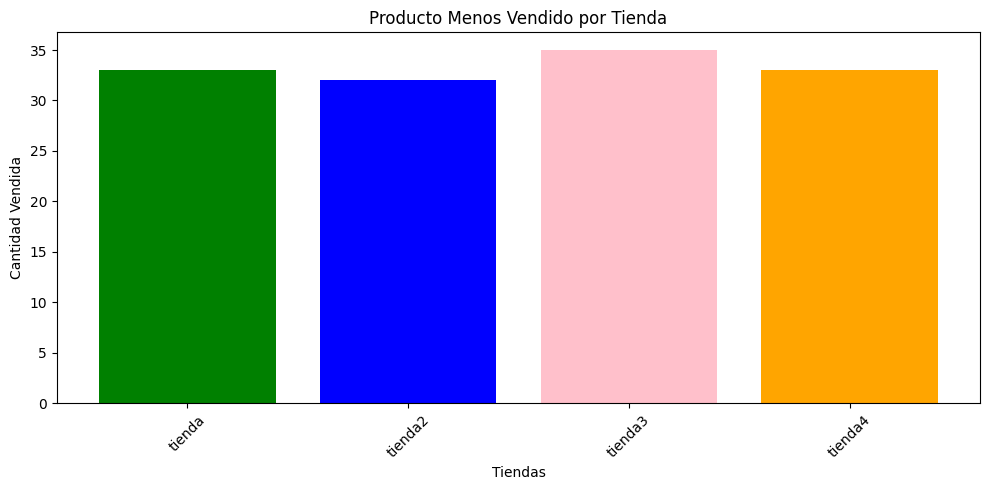

In [33]:
import matplotlib.pyplot as plt

def producto_menos_vendido(nombre_df, df, columna, columna_categoria):
    producto = df[columna].value_counts()  # cuenta cuántas veces aparece cada producto en la columna
    producto_menos_vendido = producto.idxmin()  # obtiene el nombre del producto menos vendido
    cantidad_menos_vendida = producto.min()  # obtiene la cantidad de productos menos vendidos

    # Obtener la categoría del producto menos vendido
    categoria_producto = df[df[columna] == producto_menos_vendido][columna_categoria].iloc[0]

    return producto_menos_vendido, cantidad_menos_vendida, categoria_producto

# Listas para almacenar los resultados
nombres_tiendas = ['tienda', 'tienda2', 'tienda3', 'tienda4']
dataFrames = [tienda, tienda2, tienda3, tienda4]

productos_menos_vendidos = []
cantidades_menos_vendidas = []

# Llamada a la función y almacenamiento de resultados
for nombre, df in zip(nombres_tiendas, dataFrames):
    producto, cantidad, categoria = producto_menos_vendido(nombre, df, 'Producto', 'Categoría del Producto')
    productos_menos_vendidos.append(producto)
    cantidades_menos_vendidas.append(cantidad)
    print(f"El producto menos vendido de {nombre} es: '{producto}' con {cantidad} ventas y pertenece a la categoría: '{categoria}'.")

# Definir una lista de colores para las barras
colores = ['green', 'blue', 'pink', 'orange']

# Graficar los resultados
plt.figure(figsize=(10, 5))
plt.bar(nombres_tiendas, cantidades_menos_vendidas, color=colores)
plt.title('Producto Menos Vendido por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

Se calcula el promedio de envío por tienda con .mean()

El costo de envío promedio de la tienda es de: $26018.60958033065
El costo de envío promedio de la tienda2 es de: $25216.235693090293
El costo de envío promedio de la tienda3 es de: $24805.680373039424
El costo de envío promedio de la tienda4 es de: $23459.457167090754


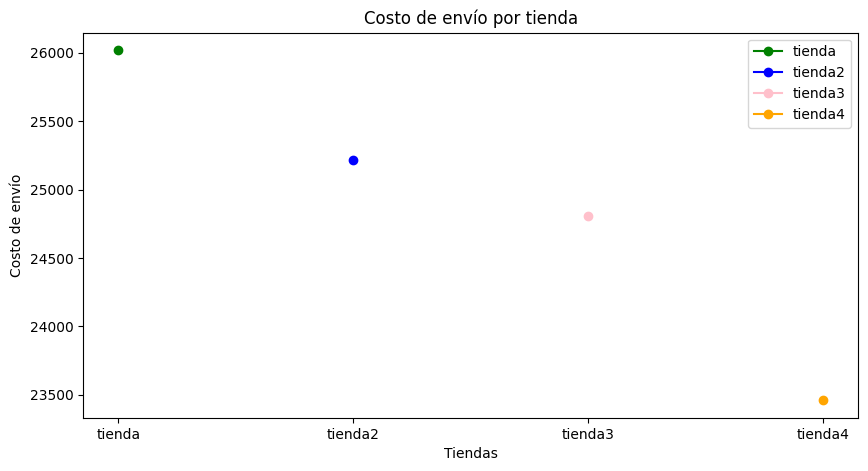

In [34]:
from matplotlib import pyplot as plt

def costo_envio(nombre_df, df, columna):
    envio = df[columna].mean()  # calcula el costo de envío promedio
    return envio

# Recopilando datos de todas las tiendas
costos_envio = []

# Guardando el nombre de las tiendas y sus DataFrames
nombre_tiendas = ['tienda', 'tienda2', 'tienda3', 'tienda4']
dataFrames = [tienda, tienda2, tienda3, tienda4]

# Bucle para calcular el costo de envío
for nombre, df in zip(nombre_tiendas, dataFrames):
    costo = costo_envio(nombre, df, 'Costo de envío')  # Llama a la función para obtener el costo de envío por tienda
    costos_envio.append(costo)  # Agrega el costo a la lista
    print(f"El costo de envío promedio de la {nombre} es de: ${costo}")

# Definir una lista de colores para los puntos
colores = ['green', 'blue', 'pink', 'orange']

# Graficando el costo de envío
plt.figure(figsize=(10, 5))
for i in range(len(nombre_tiendas)):
    plt.plot(nombre_tiendas[i], costos_envio[i], marker='o', color=colores[i], linestyle='-', label=nombre_tiendas[i])

plt.xlabel('Tiendas')  # Etiqueta del eje x
plt.ylabel('Costo de envío')  # Etiqueta del eje y
plt.title('Costo de envío por tienda')  # Título del gráfico
plt.legend()  # Añadir leyenda para identificar cada tienda
plt.show()

# Resumen

Este informe se generó para ayudar al Sr. Juan a tomar una decisión basada en datos para identificar la tienda que debe vender para iniciar un nuevo emprendimiento, esta tienda presenta una eficiencia menor en comparación a las otras 3. Puntos a considerar:

### <font color=red> Los ingresos totales de las tiendas.
**1 Análisis de facturación**

<font color=orange> La tienda no 4 tuvo menor ingreso con una facturación de: $1,038,375,700

<font color=green> La tienda no 1 tuvo mayor ingreso con una facturación de: $1,150,880,400

La diferencia entre la tienda con mayor ingreso es de: $112,504,700

### <font color=red> Las categorías de productos más y menos vendidas.
**2 Ventas por categoría**

Se muestra la categoría más vendida y el monto en ganancia, pero igual se muestra la categoría que más ganancia tuvo.

*La categoría más vendida de todas las tiendas es: 'Muebles'.*

<font color=green> La categoría menos vendida de **tienda 1** es: 'Artículos para el hogar' con 171 ventas y un total de $12,698,400

<font color=green> La categoría que generó menor venta total es: 'Libros' con un total de $8,784,900

<font color=green> La categoría más vendida de **tienda 1** es: 'Muebles' con 465 ventas y un total de $187,633,700

<font color=green> La categoría que generó mayor venta total es: 'Electrónicos' con un total de $429,493,500


<font color=blue> La categoría menos vendida de **tienda 2** es: 'Artículos para el hogar' con 181 ventas y un total de $14,746,900

<font color=blue> La categoría que generó menor venta total es: 'Libros' con un total de $10,091,200

<font color=blue> La categoría más vendida de **tienda 2** es: 'Muebles' con 442 ventas y un total de $176,426,300

<font color=blue> La categoría que generó mayor venta total es: 'Electrónicos' con un total de $410,831,100

<font color=pink> La categoría menos vendida de **tienda 3** es: 'Instrumentos musicales' con 177 ventas y un total de $77,380,900

<font color=pink> La categoría que generó menor venta total es: 'Libros' con un total de $9,498,700

<font color=pink> La categoría más vendida de **tienda 3** es: 'Muebles' con 499 ventas y un total de $201,072,100

<font color=pink> La categoría que generó mayor venta total es: 'Electrónicos' con un total de $410,775,800

<font color=orange> La categoría menos vendida de **tienda 4** es: 'Instrumentos musicales' con 170 ventas y un total de $75,102,400

<font color=orange> La categoría que generó menor venta total es: 'Libros' con un total de $9,321,300

<font color=orange> La categoría más vendida de **tienda 4** es: 'Muebles' con 480 ventas y un total de $192,528,900

<font color=orange> La categoría que generó mayor venta total es: 'Electrónicos' con un total de $409,476,100


### <font color=red> Las calificaciones promedio de los clientes por tienda.
**3 Calificación promedio de la tienda**

<font color=green> La calificación de la **tienda 1** es de: 3.97 de 5

<font color=blue> La calificación de la **tienda 2** es de: 4.03 de 5

<font color=pink> La calificación de la **tienda 3** es de: 4.04 de 5

<font color=orange> La calificación de la **tienda 4** es de: 3.99 de 5


### <font color=red> Los productos más y menos vendidos.
**4 Productos más y menos vendidos**

<font color=green> **Tienda 1** El producto más vendido es: 'Microondas' con 60 ventas y pertenece a la categoría: 'Electrodomésticos'. El producto menos vendido es: 'Auriculares con micrófono' con 33 ventas y pertenece a la categoría: 'Electrónicos'.

<font color=blue> **Tienda 2** El producto más vendido es: 'Iniciando en programación' con 65 ventas y pertenece a la categoría: 'Libros'. El producto menos vendido es: 'Juego de mesa' con 32 ventas y pertenece a la categoría: 'Juguetes'.

<font color=pink> **Tienda 3** El producto más vendido es: 'Kit de bancas' con 57 ventas y pertenece a la categoría: 'Muebles'. El producto menos vendido es: 'Bloques de construcción' con 35 ventas y pertenece a la categoría: 'Juguetes'.

<font color=orange> **Tienda 4** El producto más vendido es: 'Cama box' con 62 ventas y pertenece a la categoría: 'Muebles'. El producto menos vendido es: 'Guitarra eléctrica' con 33 ventas y pertenece a la categoría: 'Instrumentos musicales'.

### <font color=red> El coste de envío promedio para cada tienda.
**5 Envío promedio por tienda**

<font color=green> El costo de envío promedio de la **tienda 1** es de: $26,018

<font color=blue> El costo de envío promedio de la **tienda 2** es de: $25,216

<font color=pink> El costo de envío promedio de la **tienda 3** es de: $24,805

<font color=orange> El costo de envío promedio de la **tienda 4** es de: $23,459



In [28]:
import pandas as pd
from tabulate import tabulate

print("📊 Tabla Comparativa de Tiendas\n")

# Datos de comparación
data = {
    "Criterio": [
        "Ingresos totales",
        "Categoría más vendida",
        "Categoría con más ganancia",
        "Categoría con menor ganancia",
        "Calificación promedio",
        "Producto más vendido",
        "Producto menos vendido",
        "Costo envío promedio"
    ],
    "Tienda 1": [
        "✅ $1,150,880,400",
        "Muebles ($187M)",
        "Electrónicos ($429M)",
        "Libros ($8.7M)",
        "❌ 3.97",
        "Microondas (60) – Electrodomésticos",
        "Auriculares con micrófono (33) – Electrónicos",
        "❌ $26,018"
    ],
    "Tienda 2": [
        "$1,140,927,500",
        "Muebles ($176M)",
        "Electrónicos ($410M)",
        "Libros ($10M)",
        "4.03",
        "Iniciando en programación (65) – Libros",
        "Juego de mesa (32) – Juguetes",
        "$25,216"
    ],
    "Tienda 3": [
        "$1,134,328,100",
        "✅ Muebles ($201M)",
        "Electrónicos ($410M)",
        "Libros ($9.4M)",
        "✅ 4.04",
        "Kit de bancas (57) – Muebles",
        "Bloques de construcción (35) – Juguetes",
        "$24,805"
    ],
    "Tienda 4": [
        "❌ $1,038,375,700",
        "Muebles ($192M)",
        "Electrónicos ($409M)",
        "❌ Libros ($9.3M)",
        "3.99",
        "✅ Cama box (62) – Muebles",
        "❌ Guitarra eléctrica (33) – Instrumentos Musicales",
        "✅ $23,459"
    ]
}

# Crear el DataFrame
df = pd.DataFrame(data)

# Mostrar tabla con formato
print(tabulate(df, headers='keys', tablefmt='grid'))



📊 Tabla Comparativa de Tiendas

+----+------------------------------+-----------------------------------------------+-----------------------------------------+-----------------------------------------+-----------------------------------------------------+
|    | Criterio                     | Tienda 1                                      | Tienda 2                                | Tienda 3                                | Tienda 4                                            |
+====+==============================+===============================================+=========================================+=========================================+=====================================================+
|  0 | Ingresos totales             | ✅ $1,150,880,400                             | $1,140,927,500                          | $1,134,328,100                          | ❌ $1,038,375,700                                   |
+----+------------------------------+-------------------------------------

De acuerdo con en el análisis, la tienda que presenta menor eficiencia y por tanto se recomienda vender es la <font color=orange>**tienda 4**.

Esta tienda tiene el menor ingreso total, menor calificación promedio comparada con otras de mejor desempeño, y aunque su costo de envío promedio es el más bajo, este factor no compensa sus grendes debilidades generales.

# 📄 Informe Ejecutivo
**Análisis Comparativo de Tiendas – Recomendación de Venta**


Con el objetivo de tomar una decisión informada sobre cuál de sus tiendas vender para iniciar un nuevo emprendimiento, se realizó un análisis exhaustivo de desempeño sobre las cuatro tiendas en operación, considerando los siguientes factores: ingresos totales, categorías de productos, calificaciones de clientes, productos más y menos vendidos y costos de envío promedio.

## 📉 Recomendación
Se **recomienda vender** la **<font color=orange>Tienda 4**.

Presenta un desempeño inferior en comparación con las otras tres tiendas.

## 📌 Principales Hallazgos:

- **Menor ingreso total:** La Tienda 4 facturó $1,038,375,700

 Lo que representa una diferencia negativa de $112,504,700 con respecto a la tienda de mayor ingreso (Tienda 1).

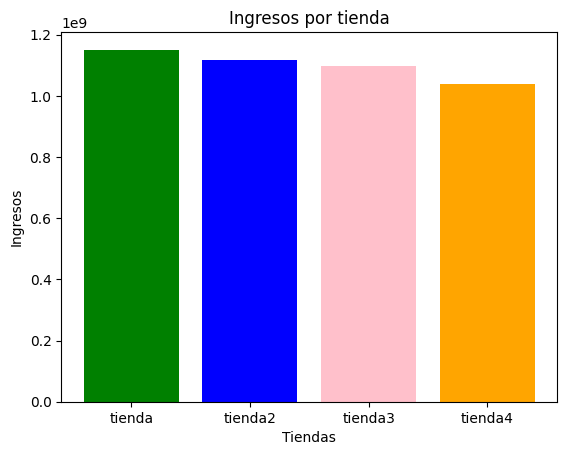

- **Calificación de clientes moderada:** Obtuvo una calificación promedio de 3.99, por debajo de Tienda 2 (4.03) y Tienda 3 (4.04), lo cual indica una experiencia de cliente ligeramente menos favorable.


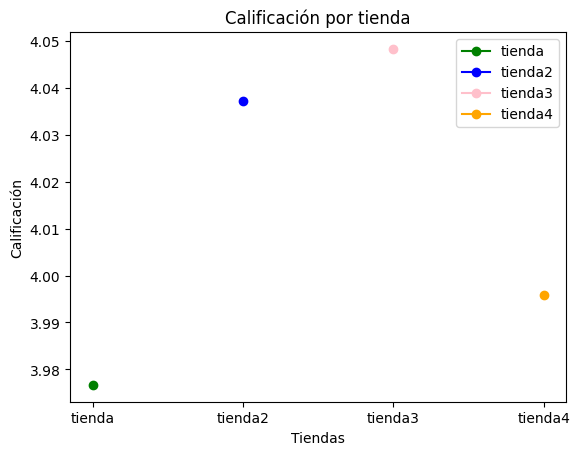

- **Categorías con menor desempeño:** Aunque 'Electrónicos' fue la categoría más rentable en general, Tienda 4 tuvo el valor más bajo dentro de esta categoría ($409,476,100).

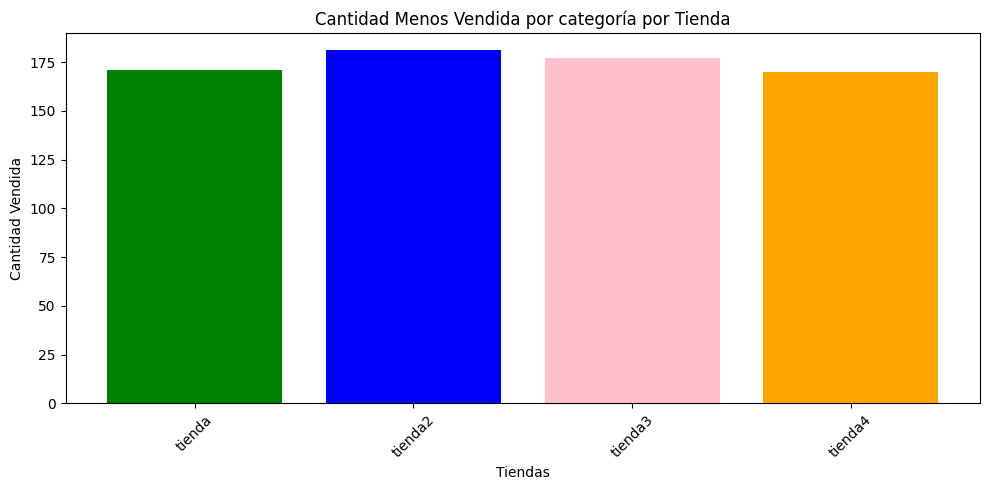


- **Producto menos vendido relevante:** La Guitarra eléctrica (Instrumentos musicales) con solo 33 ventas refleja una baja rotación en productos de alto valor.

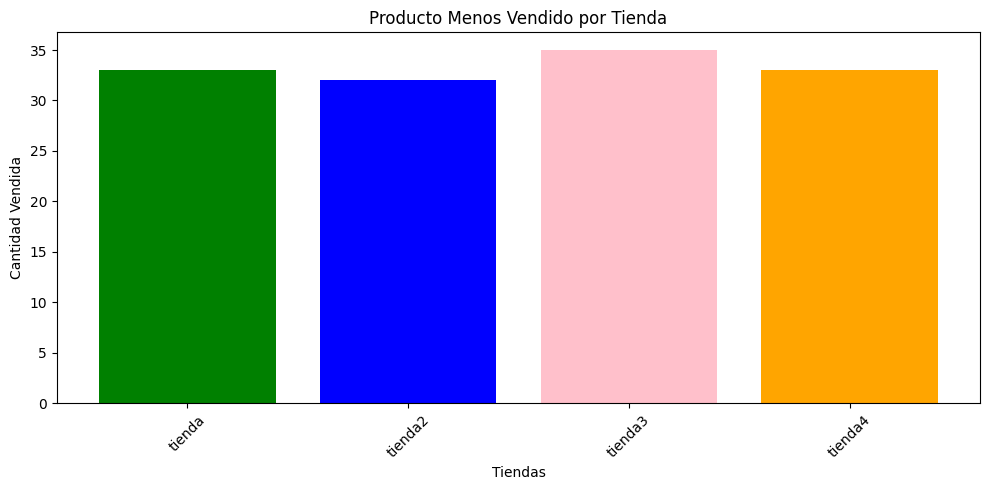

- **Único punto fuerte:** El costo de envío promedio más bajo ($23,459), lo cual no logra compensar las debilidades en ingresos y rendimiento general.

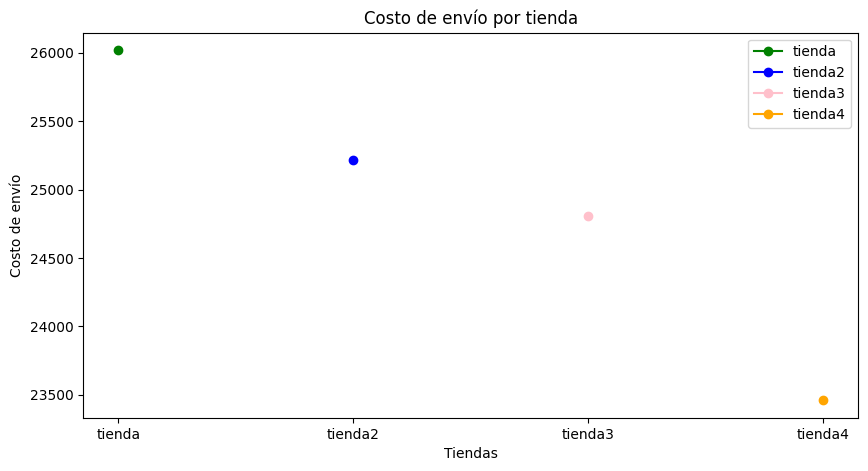

## 🛠️ Fortalezas y Debilidades Comparativas
En un análisis general, la Tienda 1 es la más sólida por ingresos; la Tienda 3 destaca por su calificación y rendimiento en muebles; la Tienda 2 es constante en desempeño. La Tienda 4, en cambio, se posiciona como la menos eficiente.

## 🧭 Conclusión
La venta de la **Tienda 4** permitirá al Sr. Juan liberar recursos de una operación menos rentable y redirigir su enfoque hacia nuevas oportunidades de negocio, optimizando así su portafolio comercial.